# 기술 통계

## 기본 설정

EDA에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

실습 데이터가 저장된 원격 저장소의 URL을 지정한다.

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 데이터셋 불러오기

In [4]:
body_info = pd.read_csv(data_url + "body_info.csv", index_col='ID')

In [5]:
body_info

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


In [6]:
body_info.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  1000 non-null   str    
 1   Age                  1000 non-null   float64
 2   Height               1000 non-null   float64
 3   Weight               1000 non-null   float64
 4   Body fat percentage  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


In [7]:
body_info['Sex'].value_counts()

Sex
F    500
M    500
Name: count, dtype: int64

기술통계 분석을 위해 `body_info` 데이터프레임의 키(Height) 데이터를 사용한다.
먼저 처음 10명의 키 데이터를 넘파이 어레이와 데이터프레임으로 각각 추출한다.

In [8]:
heights = body_info['Height'].values[:10]
heights

array([161.4, 168.1, 163.4, 164.1, 152.9, 159.7, 162.2, 157.6, 161.1,
       167.1])

In [9]:
heights_df = body_info[['Height']].head(10)
heights_df

,Height
ID,
F001,161.4
F002,168.1
F003,163.4
F004,164.1
F005,152.9
F006,159.7
F007,162.2
F008,157.6
F009,161.1


**`head()`/`tail()` 메서드**

`head()`/`tail()` 메서드에 정수 인자를 지정하면 지정된 개수의 샘플로 구성된 데이터프레임이 생성된다. 인자를 입력하지 않으면 기본값인 5가 실행된다. 따라서 처음 5명과 마지막 5명의 신체 정보는 다음과 같이 확인할 수 있다.

In [10]:
body_info.head()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2


In [11]:
body_info.tail()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6
M499,M,53.0,169.9,65.2,17.8
M500,M,30.0,173.7,67.2,20.3


## 데이터 대표값

주어진 데이터셋을 대표하는 값으로 평균값, 중앙값, 최빈값이 가장 많이 사용된다. 각 대표값들의 의미와 파이썬을 이용해 계산하는 여러가지 방법들에 대해서 살펴보자.

**평균값**

평균값은 데이터를 모두 더한 뒤, 데이터의 개수로 나눈 값을 말한다. 데이터셋이 $n$ 개의 데이터 $x_1, x_2, \cdots, x_n$로 이루어져 있다면 이 데이터셋의 평균값 $\bar x$는 다음과 같이 구한다.

$$
\bar x = \frac 1 n \sum_{i=1}^{n} x_i = \frac 1 n (x_1 + x_2 + \cdots + x_n)
$$

예를 들어, 처음 10명의 키 데이터의 평균값은 위에서 생성한 넘파이 어레이 `heights` 또는 데이터프레임 `heights_df`를 이용해 3가지 방식으로 계산할 수 있다.

- 파이썬

In [12]:
mean = sum(heights) / len(heights)
print("평균값:", mean)

평균값: 161.75999999999996


- 넘파이 어레이의 `mean()` 메서드 활용

In [13]:
np.mean(heights)

np.float64(161.76)

- 데이터프레임의 `mean()` 메서드 활용

In [14]:
heights_df.mean()

Height    161.76
dtype: float64

**중앙값**

중앙값은 데이터를 크기 순서대로 나열할 때 정확히 중앙에 위치한 값이다.
따라서 중앙값을 구하려면 먼저 값들을 크기순으로 정렬해야 한다. 이때 넘파이 어레이의 `sort()` 메서드를 사용하면 편리하다.

In [15]:
sorted_heights = np.sort(heights)
sorted_heights

array([152.9, 157.6, 159.7, 161.1, 161.4, 162.2, 163.4, 164.1, 167.1,
       168.1])

정렬한 후에 데이터 개수 n이 짝수인지 홀수인지에 따라 중앙값을 지정한다.

- n이 홀수일 때: (n+1)/2 번째 데이터
- n이 짝수일 때: n/2 번째 데이터와 (n/2) + 1 번째 데이터의 평균값

따라서 처음 10명의 키 데이터의 중앙값을 계산하는 방법은 다음과 같다.

- 파이썬

In [16]:
n = len(sorted_heights)

if n % 2 == 0:
    m0 = sorted_heights[n//2 - 1]
    m1 = sorted_heights[n//2]
    median = (m0 + m1) / 2
else:
    median = sorted_heights[(n+1)//2 - 1]

print("중앙값:", median)

중앙값: 161.8


- 넘파이 어레이의 `median()` 메서드 활용

In [17]:
np.median(heights)

np.float64(161.8)

- 데이터프레임의 `median()` 메서드 활용

In [18]:
heights_df.median()

Height    161.8
dtype: float64

**최빈값**

최빈값은 데이터에서 가장 많이 나타나는 값이다.
키 데이터처럼 연속형 데이터의 경우, 동일한 값이 여러 번 나타나는 경우가 드물 수 있다.
데이터프레임의 `mode()` 메서드를 이용하여 최빈값을 확인할 수 있다.

In [19]:
heights_df.mode()

,Height
0,152.9
1,157.6
2,159.7
3,161.1
4,161.4
5,162.2
6,163.4
7,164.1
8,167.1
9,168.1


## 데이터 분포

**편차**

각 데이터가 평균으로부터 떨어져 있는 정도를 **편차**<font size='2'>deviation</font>라 한다.
즉, 편차는 데이터들이 평균값으로부터 떨어져 있는 정도를 나타내는 값이다.

앞에서 10명의 키 데이터의 평균값을 구했으므로, 각 사람의 키 편차는 다음과 같이 계산된다.

In [20]:
mean = np.mean(heights)
print('heights의 평균값:', mean)

deviation = heights - mean
deviation

heights의 평균값: 161.76


array([-0.36,  6.34,  1.64,  2.34, -8.86, -2.06,  0.44, -4.16, -0.66,
        5.34])

평균값이 같은 데이터라 하더라도 편차는 많이 다를 수 있다.
예를 들어 다음 10명의 편차는 이전 10명의 편차보다 상대적으로 많이 작다.

In [21]:
another_heights = np.array([160.8, 162.8, 161.8, 161.0, 162.4, 162.0, 161.2, 162.6, 161.4, 161.6])

another_mean = np.mean(another_heights)
print('another_heights의 평균값:', another_mean)

another_deviation = another_heights - another_mean
another_deviation

another_heights의 평균값: 161.76


array([-0.96,  1.04,  0.04, -0.76,  0.64,  0.24, -0.56,  0.84, -0.36,
       -0.16])

`another_heights`에 포함된 데이터들의 편차가 훨씬 작다.

데이터프레임을 이용하여 동일한 결과를 확인할 수 있다.

아래 코드는 `heights_df` 데이터프레임을 복제해서 새로
생성한 데이터프레임에 편차 데이터를 추가하는 방법을 보여준다.

In [22]:
summary_df = heights_df.copy()
summary_df['deviation'] = deviation

summary_df

,Height,deviation
ID,,
F001,161.4,-0.36
F002,168.1,6.34
F003,163.4,1.64
F004,164.1,2.34
F005,152.9,-8.86
F006,159.7,-2.06
F007,162.2,0.44
F008,157.6,-4.16
F009,161.1,-0.66


`mean()` 메서드를 사용하면 각 열의 평균값을 출력하므로, 키 데이터의 평균값과 편차들의 평균값을 확인할 수 있다. 편차의 평균값은 항상 0 임에 주의한다.

In [23]:
summary_df.mean()

Height       1.617600e+02
deviation    5.684342e-15
dtype: float64

**분산**

데이터들의 편차는 항상 음수와 양수가 섞여 평균값이 0이 된다. 데이터들이 평균값을 기준으로 얼마나 떨어져 있는지를 나타내는 측정값으로는 적절치 않다. 이러한 용도로 쓰이는 값이 바로 지금부터 소개할 분산<font size='2'>variance</font>과 표준편차<font size='2'>standard deviation</font>이다.

**분산**<font size='2'>variance</font>는 편차의 제곱의 평균값이며, 계산식은 다음과 같다.

$$
S^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + (x_2 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$

`heights`에 포함된 10명의 키 데이터의 분산은 편차의 제곱에 `mean()` 메서드를 적용해 구할 수 있다.

In [24]:
np.mean(deviation ** 2)

np.float64(17.768399999999986)

넘파이의 `var()`와 데이터프레임의 `var()` 메서드를 활용해 구해도 된다. 하지만 데이터프레임을 이용할 때는 `ddof=0` 키워드 인자를 사용해 (편향된) 표본분산<font size='2'>sample variance</font>을 계산토록 해야한다.


In [25]:
np.var(heights)

np.float64(17.768399999999986)

In [26]:
heights_df.var(ddof=0)

Height    17.7684
dtype: float64

`ddof` 키워드 인자를 생략하면 `ddof=1`로 지정된 기본 옵션이 실행되며
불편분산<font size='2'>unbiased variance</font>, 즉 편향되지 않은 표본분산을 계산한다. 편향분산<font size='2'>biased variance</font>과 불편분산의 구분은 잠시 후에 설명한다.

In [27]:
heights_df.var()

Height    19.742667
dtype: float64

In [28]:
heights_df.var(ddof=0)

Height    17.7684
dtype: float64

한편, `np.var()` 함수 또한 `ddof` 키워드 인자를 사용할 수 있는데, 기본값은 데이터프레임의 경우와는 달리 0으로
지정되어 있어서 기본적으로 편향분산을 계산한다.

In [29]:
np.var(heights, ddof=0)

np.float64(17.768399999999986)

`ddof=1`로 지정하면 불편분산을 계산한다.

In [30]:
np.var(heights, ddof=1)

np.float64(19.74266666666665)

:::{admonition} 편향분산 vs. 불편분산
:class: note

불편분산을 이해하려면 먼저 모집단과 표본 개념을 이해해야 한다.

- 모집단: 분석 대상인 모든 데이터. (ex) 전 세계인들의 몸무게
- 표본: 분석 대상인 모집단으로부터 추출한 일부 데이터. (ex) 모든 국가에서 국가별 100명을 무작위로 선택해 얻은 몸무게 데이터
- 모분산: 모집단의 분산
- 표본분산: 표본의 분산

모집단 데이터는 일반적으로 구하기가 매우 어렵거나 불가능할 수 있다.
따라서 모평균과 모분산은 표본들의 평균값과 분산으로 적절한
신뢰도와 함께 추정한다.

n개 표본 샘플 편차의 제곱의 평균값을 편향분산<font size='2'>biased variance</font>이라고 하고, 이때 분모를 n이 아닌 n-1로 바꾼 값을 불편분산<font size='2'>unbiased variance</font>이라고 한다. 불편분산의 기댓값을 구하면 모분산의 추정값이 된다는 것이 수학적으로 증명되며, 자세한 설명은 [불편추정량에 대한 고백](https://recipesds.tistory.com/entry/왜-표본분산은-n-1로-나누죠-자유도-불편추정량에-대한-고백)에서 찾아볼 수 있다.
:::

아래 코드는 편차의 제곱을 새로운 변수 `summary_df`가 가리키는 데이터프레임의 새로운 특성(변인)으로 추가한다.

In [31]:
summary_df['square of deviation'] = np.square(deviation)
summary_df

,Height,deviation,square of deviation
ID,,,
F001,161.4,-0.36,0.1296
F002,168.1,6.34,40.1956
F003,163.4,1.64,2.6896
F004,164.1,2.34,5.4756
F005,152.9,-8.86,78.4996
F006,159.7,-2.06,4.2436
F007,162.2,0.44,0.1936
F008,157.6,-4.16,17.3056
F009,161.1,-0.66,0.4356


각 특성의 평균값을 계산하면 앞서 `heights`에 포함된 데이터들의 평균값, 편차 평균값, (편향)분산이 확인된다.

In [32]:
summary_df.mean()

Height                 1.617600e+02
deviation              5.684342e-15
square of deviation    1.776840e+01
dtype: float64

**표준편차**

분산은 편차 제곱의 평균값이므로, 원래 데이터에 사용된 단위가 아닌 해당 단위의 제곱을 사용한다.
앞서 보았던 정사각형의 한 변의 길이와 면적은 단위가 다른 것과 같다. 따라서 동일한 단위로 데이터의 분포도를 측정하는 용도로 분산의 제곱근인 **표준편차**<font size='2'>standard deviation</font>를 활용한다.

$$
S = \sqrt{S^2} = \sqrt{\frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2}
$$

10명의 키 데이터의 표준편차는 넘파이의 제곱근 함수인 `np.sqrt()`를 이용해 직접 계산하거나, 넘파이의 `np.std()` 함수를 바로 이용해도 된다.

In [36]:
np.sqrt(np.var(heights))

np.float64(4.215257999221398)

In [37]:
np.std(heights)

np.float64(4.215257999221398)

단, 데이터프레임의 `std()` 메서드를 사용할 때는 앞에서처럼 편향분산을 위한 `ddof=0` 옵션을 함께 지정해야 한다.

In [38]:
heights_df.std(ddof=0)

Height    4.215258
dtype: float64

**범위**

**범위**<font size='2'>range</font>는 데이터의 최댓값과 최솟값의 차이를 가리킨다.

$$
Rg = x_{\max} - x_{\min}
$$

`heights`에 포함된 데이터의 범위는 다음과 같이 구한다.

In [39]:
np.max(heights) - np.min(heights)

np.float64(15.199999999999989)

범위는 최댓값과 최소값이 변하면 그에 따라 값이 크게 요동칠 수 있다.
따라서 데이터 분포를 이해하는 데는 범위 대신 데이터의 변화에 덜 민감한 사분위수와 사분범위가 주로 이용된다.

**사분위수와 사분범위**

데이터의 하위 25%, 50%, 75%에 위치하는 값을
각각 제1사분위수(Q1), 제2사분위수(Q2), 제3사분위수(Q3)라 한다.
Q2는 앞서 살펴본 중앙값에 해당한다.

**사분범위**<font size='2'>interquartile range</font>는 제3사분위수에서 제1사분위수를 뺀 값으로서, 평균값을 중심으로 50%의 데이터가 모여있는 구간의 길이를 나타낸다.
아래 코드는 `heights`의 사분범위 `heights_IQR`을 계산하는데,
`np.percentile()` 함수는 지정된 %에 해당하는 값을 반환하는 함수이다.

In [40]:
heights_Q1 = np.percentile(heights, 25)
heights_Q3 = np.percentile(heights, 75)
heights_IQR = heights_Q3 - heights_Q1
heights_IQR

np.float64(3.8750000000000284)

**상자 그림**

상자 그림은 데이터의 범위, 사분위수, 사분범위를 동시에 보여준다.
상자 그림은 다음 값들을 점, 선분, 직사각형 등으로 표시하는데,
그림에 표시되는 값들을 위에서부터 나열하면 다음과 같다.

- 너무 큰 이상치<font size='2'>outlier</font>에 해당하는 점들
- (Q3 + 1.5 * IQR)에 해당하는 값의 수평 선분
- Q3, Q2, Q1에 해당하는 값을 이용한 직사각형
- (Q1 - 1.5 * IQR)에 해당하는 값의 수평 선분
- 너무 작은 이상치<font size='2'>outlier</font>에 해당하는 점들

이제 데이터프레임 `summary_df`의 `boxplot()` 메서드를 이용하여 `Height` 특성에 포함된 값들을 대상으로 상자 그림을 그린다.

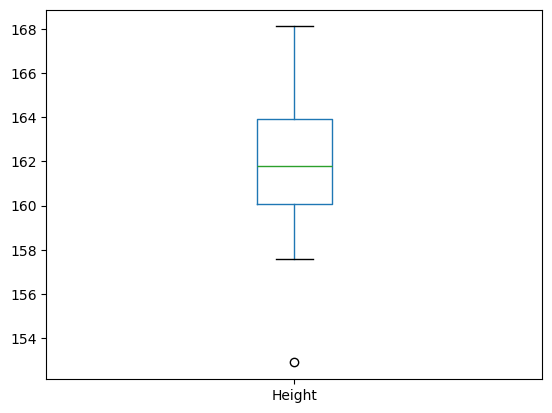

In [41]:
summary_df.boxplot(column=['Height'], grid=False)
plt.show()

**데이터프레임의 `describe()` 메서드**

데이터프레임의 `describe()` 메서드는
데이터의 개수, 평균값, 표준편차, 최댓값, 최소값, 사분위수에 대한 정보를 담고있는 데이터프레임을 생성한다.

In [42]:
heights_df = summary_df[['Height']]
heights_df.describe()

,Height
count,10.000000
mean,161.760000
std,4.443272
min,152.900000
25%,160.050000
50%,161.800000
75%,163.925000
max,168.100000


## 연습문제

참고: [(연습) 1차원 데이터](https://colab.research.google.com/github/codingalzi/statsRev/blob/master/practices/practice-oneD_data.ipynb)